In [2]:
from firedrake import *
import matplotlib.pyplot as plt
import numpy as np
from firedrake.petsc import PETSc
# Get current path: all relative paths that you may use for input/output start from here.
#
# - Colab:  The default path is /content, and your GDrive folder is accessible (if mounted) at /content/drive/MyDrive
#
# - local:  If running on your local machine, current_path is the position WHERE YOU LAUNCHED THE NOTEBOOK KERNEL BY 'jupyter notebook'
#           and NOT the directory in which this ipynb file is saved.
#           If you want to modify your current path, go to the terminal, stop the kernel (ctrl-C + press y), then move to the desired path by
#           cd my/desired/path/starting/from/here
#           and then launch 'jupyter notebook'.
import os
current_path = os.getcwd()
print(current_path)

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


/home/aless/cfd-labs/Lab13-Inexact-Factorization


# Utilities
IterationMonitor

In [39]:
class IterationMonitor(object):
  def __init__(self, solver, dt):
    self.solver = solver
    self.iteration_log = []
    self.t = 0.0

  def update(self):
    outer_snes_its = self.solver.snes.getIterationNumber()
    outer_ksp_its  = self.solver.snes.ksp.getIterationNumber()

    # Extract fieldsplit details
    pc = self.solver.snes.ksp.getPC()
    pc.setUp()

    # Get fieldsplit sub-KSPs
    subksps = pc.getFieldSplitSubKSP()

    vel_its = subksps[0].getIterationNumber()
    pres_its = subksps[1].getIterationNumber()

    # If each sub-solver has its own PC with inner iterations:
    vel_pc = subksps[0].getPC()
    pres_pc = subksps[1].getPC()

    # Optional: inner iterations of approximate Schur complement solve
    try:
        vel_inner_its = vel_pc.getKSP().getIterationNumber()
    except:
        vel_inner_its = None

    try:
        pres_inner_its = pres_pc.getKSP().getIterationNumber()
    except:
        pres_inner_its = None

    self.t += dt

    self.iteration_log.append(dict(
        step=self.t,
        outer_snes=outer_snes_its,
        outer_ksp=outer_ksp_its,
        vel_iters=vel_its,
        pres_iters=pres_its,
        vel_inner=vel_inner_its,
        pres_inner=pres_inner_its,
    ))


# Ex.1 Algebraic Chorin-Temam projection method

We want to solve the following problem for the time-dependent Navier-Stokes equations using the algebraic Chorin-Temam method:

$$
\begin{cases}
\displaystyle 
\frac{\partial u}{\partial t}
+ (u \cdot \nabla)u
- \frac{2}{\mathrm{Re}}\,\varepsilon(u)
+ \nabla p = 0,
& \text{in } \Omega,\\
\nabla \cdot u = 0,
& \text{in } \Omega,\\
u = u_{\text{in}} & \text{on } \Gamma_1,\\
\left( -pI + \frac{2}{\mathrm{Re}} \varepsilon(u) \right) \cdot n = 0. & \text{on } \Gamma_2 \\
u \cdot n = 0,\quad n \cdot 2\mu \varepsilon(u)\,\tau = 0 & \text{on } \Gamma_3 \cup \Gamma_4 \\
u = 0. & \text{on } \Gamma_5 \\
u (x,0) = u_{\text{Stokes}} & \text{in } \Omega
\end{cases}
$$

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (5,) is empty. This is likely an error. Did you choose the right label?


(np.float64(-3.75), np.float64(12.75), np.float64(-2.2), np.float64(2.2))

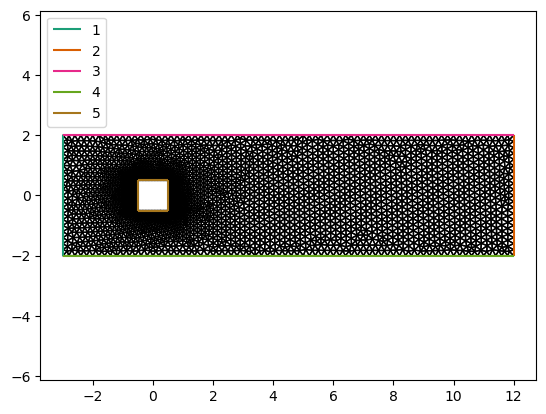

In [40]:
# Import mesh: set the path correctly!
mesh = Mesh('mesh/squareCyl.msh')
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend(loc='upper left')
ax.axis('equal')

In [41]:
# Function spaces
# Bubble enrichment of the velocity space
V1_el = FiniteElement('CG', mesh.ufl_cell(), 1)
B_el = FiniteElement('Bubble', mesh.ufl_cell(), mesh.topological_dimension + 1)
V_el = VectorElement(NodalEnrichedElement(V1_el, B_el))
V = FunctionSpace(mesh, V_el)
Q = FunctionSpace(mesh, 'P', 1)
W = MixedFunctionSpace([V, Q])
print('Dimensions')
print('-'*20)
print('V :', V.dim())
print('Q :', Q.dim())
print('W :', W.dim())

# Data
Re = 20
f = Constant((0., 0.))
t = 0
T = 4.0
dt = 0.01

# Boundary conditions
x = SpatialCoordinate(mesh)

# Inlet Dirichelt condition
u_in = as_vector((3/8*(2-x[1])*(2+x[1]), 0.0))
bc_inlet = DirichletBC(W.sub(0), u_in, 1)

# Homogeneous Nuemann condition for the outlet
# / 

# Free-slip Neumann condition for the top and bottom walls
bc_walls = DirichletBC(W.sub(0).sub(1), 0.0, (3, 4))

# No-slip Dirichelt condition for the cylinder
bc_cylinder = DirichletBC(W.sub(0), (0.0, 0.0), 5)

bcs = [bc_inlet, bc_walls, bc_cylinder]

Dimensions
--------------------
V : 16836
Q : 2896
W : 19732


We rely on the following scheme, which is an adaptation of the CT method. In particular, note that it is incremental with respect to the velocity too and we don't have boundary conditions in the algebraic formulation, in fact we exploit that the Dirichlet boundary conditions for the problem are constant in time and we impose them at the first time step.

1. Incremental predictor step: solve
    $$
    C^{n+1}\,\delta\tilde{U} = -N(U^n)U^n - AU^n - B^TP^n
    $$
2. Pressure/projection step.
    $$
    \tilde{\Sigma}
    \begin{bmatrix} \delta U \\ \delta P \end{bmatrix}
    =
    \begin{bmatrix} \delta \tilde{U} \\ -BU^n \end{bmatrix}
    $$

    where:

    $$
    \tilde{\Sigma} =
    \begin{bmatrix} M & B^T \\ -B & 0 \end{bmatrix}
    \approx
    \begin{bmatrix} M & 0 \\ -B & \tilde{S} \end{bmatrix}
    \begin{bmatrix} I & M^{-1}B^T \\ 0 & I \end{bmatrix}
    $$

    with $\tilde{S} = B\,M^{-1}B^T$, and $M$ being velocity mass matrix multiplied by $1/\Delta t$.


3. Update.
    $$
    U^{n+1} = U^n + \delta U
    $$

    $$
    P^{n+1} = P^n + \delta P
    $$

In [42]:
# Variational problems

# Forms for original monolithic problem - backward Euler with semi-implicit advection - pressure-incremental form
def monolithic_forms(u, v, dp, q, Re, dt, u_in, u_old, p_old):
    a = Constant(1.0/dt) * inner(u, v) * dx + inner(dot(grad(u), u_old), v) * dx + 2.0/Re*inner(sym(grad(u)), sym(grad(v))) * dx - div(v) * dp * dx + div(u)* q * dx
    L = Constant(1.0/dt) * inner(u_old, v) * dx - inner(grad(p_old), v) * dx
    return a, L

# Forms for predictor problem (u_old = u^n -> incremental du_tilde)
def predictor_forms(du, v, Re, dt, u_in, u_old, p_old):
    a = Constant(1.0/dt) * inner(du, v) * dx + inner(dot(grad(du), u_old), v) * dx + 2.0/Re*inner(sym(grad(du)), sym(grad(v))) * dx
    L = - 2.0/Re*inner(sym(grad(u_old)), sym(grad(v))) * dx - inner(grad(p_old), v) * dx - inner(dot(grad(u_old), u_old), v) * dx
    return a, L

# Forms for approximated system "C-T style" (pressure/projection step)
def monolithic_CT_forms(du, v, dp, q, Re, dt, u_in, du_tilde, u_old, p_old):
    a = Constant(1.0/dt) * inner(du, v) * dx + q * div(du) * dx - div(v) * dp * dx
    L = Constant(1.0/dt) * inner(du_tilde, v) * dx - div(u_old) * q * dx
    return a, L

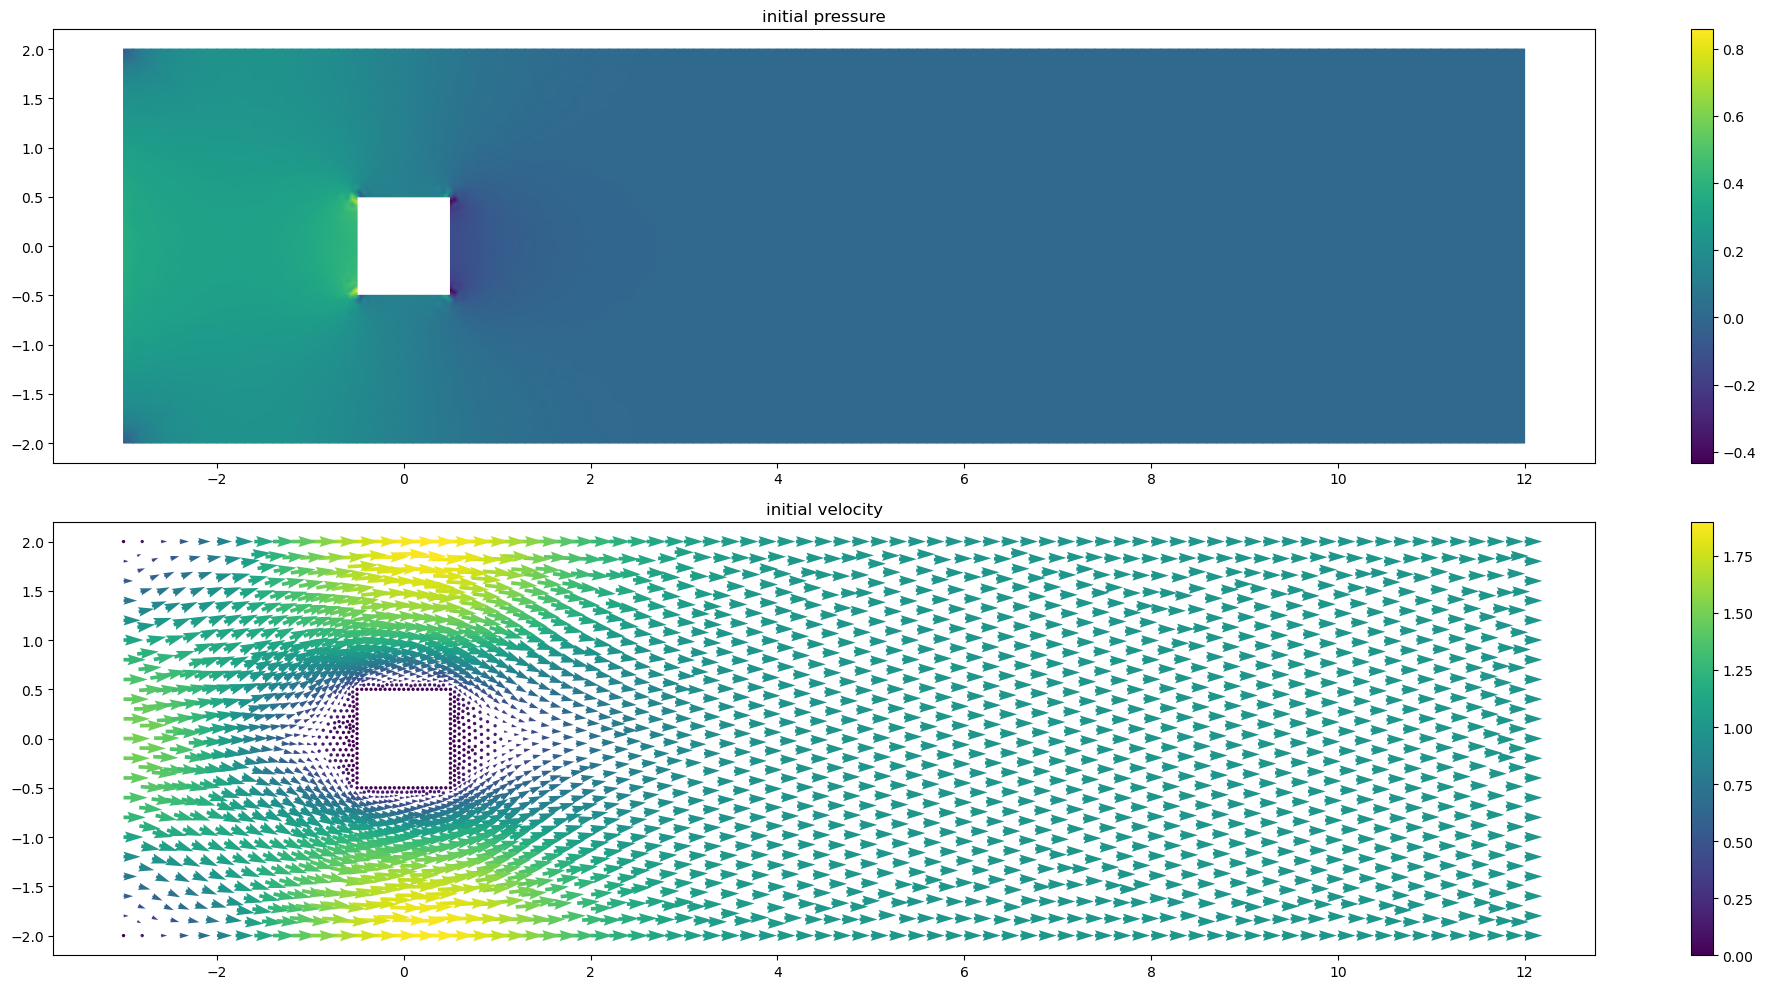

In [43]:
# Initial condition: solve Stokes problem to get initial velocity and pressure fields

# Trial and test functions
uu, pp = TrialFunctions(W)
vv, qq = TestFunctions(W)

# Variational problem
a_init = (2/Re)*inner(sym(grad(uu)), sym(grad(vv)))*dx - pp * div(vv) * dx + div(uu) * qq *dx
L_init = inner(f, vv)*dx # + inner(neumann_data, vv)*ds(neumann_tag) Homogeneous Neumann condition for the outlet

wh_init = Function(W)
solve(a_init == L_init, wh_init, bcs=bcs)
uh_init, ph_init = wh_init.subfunctions

# Initial velocity and pressure fields
uh_old = Function(V)
ph_old = Function(Q)
uh_old.assign(uh_init)
ph_old.assign(ph_init)

fig, ax = plt.subplots(2, 1, figsize=(20, 10))

col0 = tripcolor(ph_old, axes=ax[0])
fig.colorbar(col0, ax=ax[0])
ax[0].set_title('initial pressure')

col1 = quiver(uh_old, axes=ax[1])
fig.colorbar(col1, ax=ax[1])
ax[1].set_title('initial velocity')

plt.tight_layout()

# vtk output for Paraview
outdir = "output/"
outfile = VTKFile(outdir+"solution.pvd")
uh_old.rename("Velocity")   # this names will be used in Paraview
ph_old.rename("Pressure")
outfile.write(uh_old, ph_old)

In [44]:
# Deifinition of the algebraic system

du_pred = TrialFunction(V)  # incremental already in the predictor step
v_pred = TestFunction(V)
du, dp = TrialFunctions(W)  # incremental in both u and p
v, q = TestFunctions(W)

# Solution variables: for the predictor problem and then for the rest
du_tilde = Function(V)      # solution of the predictor step
wh = Function(W)            # solution of the remaining steps
duh, dph = wh.subfunctions  # incremental in both u and p

# First step: predictor problem (u_old = u^n -> incremental du_tilde)
# Homogenous Dirichlet conditions
a_pred, L_pred = predictor_forms(du_pred, v_pred, Re, dt, u_in, uh_old, ph_old)
bc_inlet_zero_pred = DirichletBC(V, Constant((0., 0.)), 1)
bc_inlet_pred = DirichletBC(V, u_in, 1)
bc_walls_pred = DirichletBC(V.sub(1), 0.0, (3, 4))
bc_cylinder_pred = DirichletBC(V, Constant((0., 0.)), 5)
bcs_zero_pred = (bc_inlet_zero_pred, bc_walls_pred, bc_cylinder_pred)
pb_pred = LinearVariationalProblem(a_pred, L_pred, du_tilde, bcs=bcs_zero_pred)

# Second step: approximated system "C-T style" (pressure/projection step)
# No boundary conditions are needed for the incremental problem, since the Dirichlet conditions are already satisfied by the predictor step
a_CT, L_CT = monolithic_CT_forms(du, v, dp, q, Re, dt, u_in, du_tilde, uh_old, ph_old)
pb_CT = LinearVariationalProblem(a_CT, L_CT, wh)

# actual non-homogeneous conditions (used afterwards)
bc_in_pred = DirichletBC(V, u_in, 1)
bcs_pred = (bc_in_pred, bc_walls_pred, bc_cylinder_pred)

In [45]:
# Solver parameters: extracting LDU factorization using fieldsplit
param = {'ksp_type': 'gmres',                                                   # applying the preconditioner once corresponds to solve the system associated to it
        'pc_type': 'fieldsplit',                                                # exploit block structure
        'pc_fieldsplit_type': 'schur',                                          # LU factorization type that is based on the computation of the Schur complement
        'pc_fieldsplit_schur_fact_type': 'full',                                # full/additive/multiplicative
        # Then, for each of the two diagonal block, we need to choose a solver to "invert" them
        'fieldsplit_0_ksp_type': 'preonly',                                     # direct solver for matrix C^{n+1}
        #'fieldsplit_0_ksp_type': 'gmres',  'fieldsplit_0_ksp_rtol': 1e-10,     # iterative solver for matrix C^{n+1}
        'fieldsplit_0_pc_type': 'ilu',                                          # preconditioner (if iterative) / solver (if preonly) for matrix C^{n+1}
        'fieldsplit_1_ksp_type': 'preonly', 'fieldsplit_1_pc_type': 'lu'        # iterative solver for matrix S^{n+1}
}
print(param)


{'ksp_type': 'gmres', 'pc_type': 'fieldsplit', 'pc_fieldsplit_type': 'schur', 'pc_fieldsplit_schur_fact_type': 'full', 'fieldsplit_0_ksp_type': 'preonly', 'fieldsplit_0_pc_type': 'ilu', 'fieldsplit_1_ksp_type': 'preonly', 'fieldsplit_1_pc_type': 'lu'}


In [46]:
# Predictor step
solver_pred = LinearVariationalSolver(pb_pred, solver_parameters={'ksp_type': 'preonly', 'pc_type': 'lu'})

# Chorin-Temam (after the predictor step, which is managed by solver_pred)
param = {
        'ksp_type': 'preonly',
        'ksp_rtol': 1e-6,
        'pc_type': 'fieldsplit',                        # exploit block structure
        'pc_fieldsplit_type': 'schur',                  # LU factorization type that is based on the computation of the Schur complement
        'pc_fieldsplit_schur_fact_type': 'full',
        # PARAMETERS TO "INVERT" VEL-VEL BLOCK. BEWARE: THEY ARE USED ALSO TO ASSEMBLE S
        'fieldsplit_0_ksp_type': 'preonly',             # direct solver for matrix A00
        'fieldsplit_0_pc_type': 'lu',
        # PARAMETERS TO "INVERT" APPROXIMATE SCHUR COMPLEMENT USING diag(A00)
        'pc_fieldsplit_schur_precondition': 'selfp',    # assemble S as S=A11-A10*inv(diag(A00))*A01=-B*inv(diag(M))*B^T : thanks to diag, inv is actually assembled!
        "fieldsplit_1_ksp_type": "preonly",             # solver for S (direct solver allowed because of selfp)
        "fieldsplit_1_pc_type": "lu",                   # preconditioner for S
        # PARAMETERS TO "INVERT" ACTUAL SCHUR COMPLEMENT (VERY EXPENSIVE)
        # 'pc_fieldsplit_schur_precondition': 'full',   # define S (without actually computing inv(M)) as S=A11-A10*inv(A00)*A01=-B*inv(M)*B^T
        # "fieldsplit_1_ksp_type": "gmres",             # solver for S (direct solver not allowed: there is inv(M) is NOT assembled)
        # "fieldsplit_1_pc_type": "lu",
}
# Other parameters to inspect the settings and behavior of the solver
param.update({"ksp_converged_reason": None,
    # "ksp_monitor_true_residual": None,
    # "ksp_view": None,
    # "fieldsplit_1_inner_ksp_view": None,
    # "fieldsplit_0_ksp_converged_reason": None,
    # "fieldsplit_0_ksp_monitor_true_residual": None,
    # "fieldsplit_1_ksp_converged_reason": None,
    # "fieldsplit_1_ksp_monitor_true_residual": None,
    # "fieldsplit_1_inner_ksp_converged_reason": None,
    # "fieldsplit_1_inner_ksp_monitor_true_residual": None,
})

# Construction of the solver.
solver = LinearVariationalSolver(pb_CT, solver_parameters=param)

iteration_monitor = IterationMonitor(solver, dt) # to collect info on solver

# Function solving 1 time step:
# - before the call: uh_old, ph_old contain the solution at the previous time step t^n
# - during the call: uh_old, ph_old, du_tilde and possibly other variables change, as long as they are correctly linked together
# - after the call: uh_old, ph_old contain the solution at the previous time step t^{n+1}
def solve_1_timestep():
    solver_pred.solve()
    solver.solve()

    # Update old solution - BEWARE: incremental!
    uh_old.dat += duh.dat
    ph_old.dat += dph.dat

    # Re-assign BCs to uh_old to contain machine error accumulation that would spoil BCs
    for bc in bcs_pred:
        bc.apply(uh_old)


### Time-dependent solution

In [47]:
# Initialization (already done above, but re-introducing it here makes the notebook more robust w.r.t. running cells in a different order... as done below for SIMPLE)
wh.assign(0)
du_tilde.assign(0)
uh_old.assign(uh_init)
ph_old.assign(ph_init)

t_vec = [0.0] + (dt + np.arange(0.0, T, dt)).tolist()
drag_vec = [0.0] * len(t_vec)
lift_vec = [0.0] * len(t_vec)
normal = FacetNormal(mesh)
drag_vec[0] = assemble(inner(ph_old*normal - 2.0/Re*dot(sym(grad(uh_old)), normal), Constant((1.,0.))) * ds(5))
lift_vec[0] = assemble(inner(ph_old*normal - 2.0/Re*dot(sym(grad(uh_old)), normal), Constant((0.,1.))) * ds(5))
iters = [solver.snes.ksp]
for ii in range(1, len(t_vec)):     # start from 1 to skip t=0
    t = t_vec[ii]
    print('------------------------------\n t =', t, '\n------------------------------')
    print('------ ||u||_{H^1} =', norm(uh_old,'H1'), '  ||p||_{L^2} =', norm(ph_old,'L2')) # to check the solution is not blowing up

    solve_1_timestep()

    print('------ # iter block linear solver = ', solver.snes.ksp.getIterationNumber(), flush=True)

    iteration_monitor.update()

    # Post-processing
    outfile.write(uh_old, ph_old, time=t)

    drag_vec[ii] = assemble(inner(ph_old*normal - 2.0/Re*dot(sym(grad(uh_old)), normal), Constant((1.,0.))) * ds(5))
    lift_vec[ii] = assemble(inner(ph_old*normal - 2.0/Re*dot(sym(grad(uh_old)), normal), Constant((0.,1.))) * ds(5))

    print('------ drag =', drag_vec[ii], '   lift =', lift_vec[ii])

------------------------------
 t = 0.01 
------------------------------
------ ||u||_{H^1} = 9.498633156400926   ||p||_{L^2} = 0.8837185479968951
    Linear firedrake_17_ solve converged due to CONVERGED_ITS iterations 1
------ # iter block linear solver =  1
------ drag = 1.0202207237717411    lift = 0.0014054809488481068
------------------------------
 t = 0.02 
------------------------------
------ ||u||_{H^1} = 9.499595322367089   ||p||_{L^2} = 1.0570737985471446
    Linear firedrake_17_ solve converged due to CONVERGED_ITS iterations 1
------ # iter block linear solver =  1
------ drag = 1.027884068468136    lift = 0.0009358011558105599
------------------------------
 t = 0.03 
------------------------------
------ ||u||_{H^1} = 9.501691864890255   ||p||_{L^2} = 1.3686973937285614
    Linear firedrake_17_ solve converged due to CONVERGED_ITS iterations 1
------ # iter block linear solver =  1
------ drag = 1.035422438839226    lift = 0.000390836962607238
-------------------------

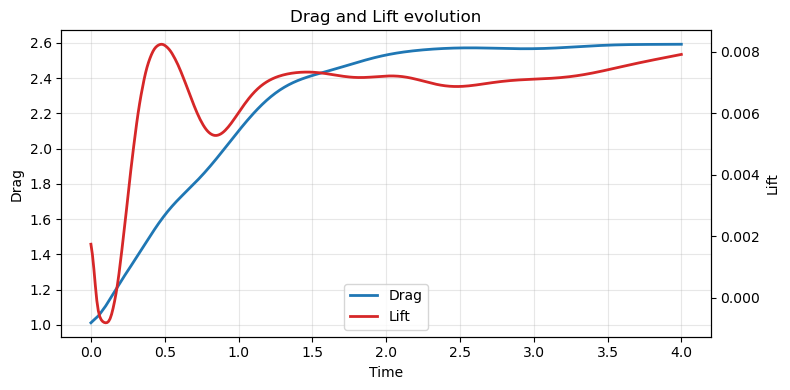

In [61]:
fig, ax1 = plt.subplots(figsize=(8, 4))

t_vec = [0.0] + (dt + np.arange(0.0, T, dt)).tolist()

# Drag axis
line1 = ax1.plot(
    t_vec, drag_vec,
    label='Drag',
    linewidth=2
)
ax1.set_xlabel('Time')
ax1.set_ylabel('Drag')
ax1.grid(True, alpha=0.3)

# Lift axis
ax2 = ax1.twinx()

line2 = ax2.plot(
    t_vec, lift_vec,
    label='Lift',
    color='tab:red',
    linewidth=2
)

ax2.set_ylabel('Lift')
ax2.tick_params(axis='y')

# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]

ax1.legend(
    lines,
    labels,
    loc='lower center',
    frameon=True
)

plt.title('Drag and Lift evolution')
plt.tight_layout()
plt.show()

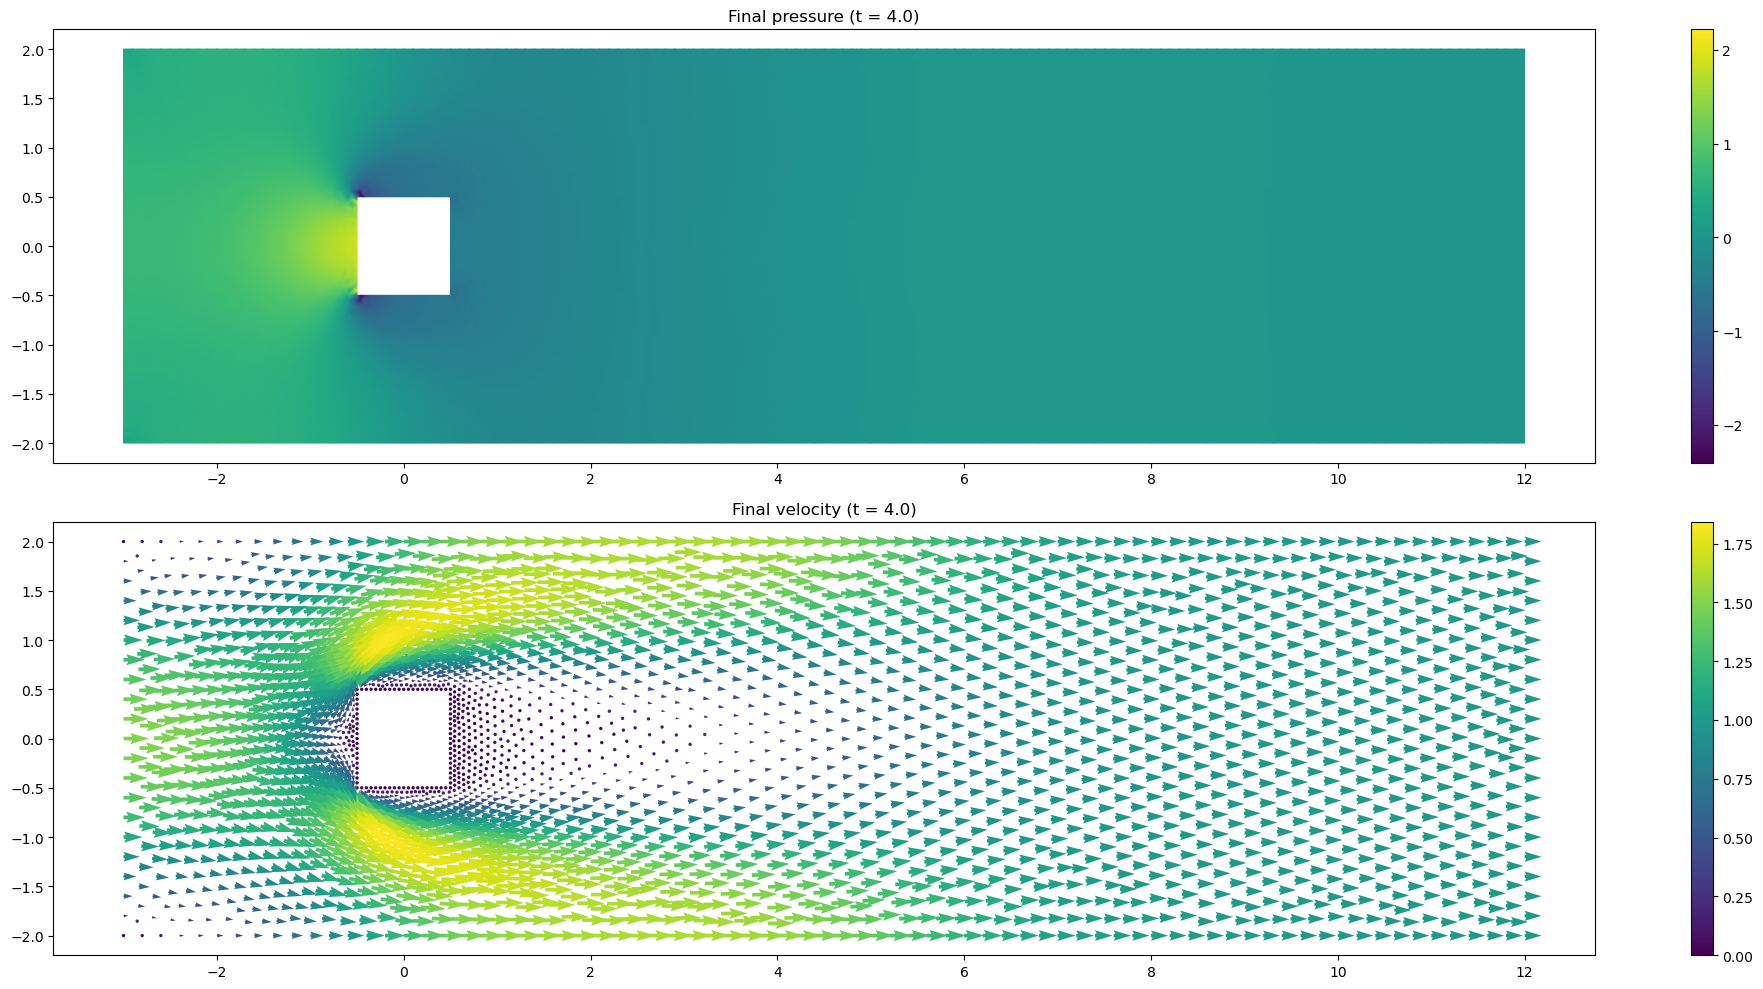

In [62]:
fig, ax = plt.subplots(2, 1, figsize=(20, 10))

col0 = tripcolor(ph_old, axes=ax[0])
fig.colorbar(col0, ax=ax[0])
ax[0].set_title('Final pressure (t = {})'.format(t_vec[-1]))

col1 = quiver(uh_old, axes=ax[1])
fig.colorbar(col1, ax=ax[1])
ax[1].set_title('Final velocity (t = {})'.format(t_vec[-1]))

plt.tight_layout()

{'step': 0.01, 'outer_snes': 1, 'outer_ksp': 1, 'vel_iters': 1, 'pres_iters': 1, 'vel_inner': None, 'pres_inner': None}
{'step': 0.02, 'outer_snes': 1, 'outer_ksp': 1, 'vel_iters': 1, 'pres_iters': 1, 'vel_inner': None, 'pres_inner': None}


<Figure size 1000x400 with 0 Axes>

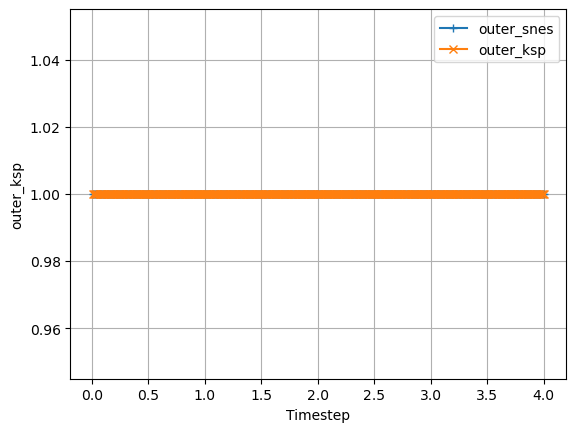

{'step': 0.01, 'outer_snes': 1, 'outer_ksp': 1, 'vel_iters': 1, 'pres_iters': 1, 'vel_inner': None, 'pres_inner': None}
{'step': 0.02, 'outer_snes': 1, 'outer_ksp': 1, 'vel_iters': 1, 'pres_iters': 1, 'vel_inner': None, 'pres_inner': None}


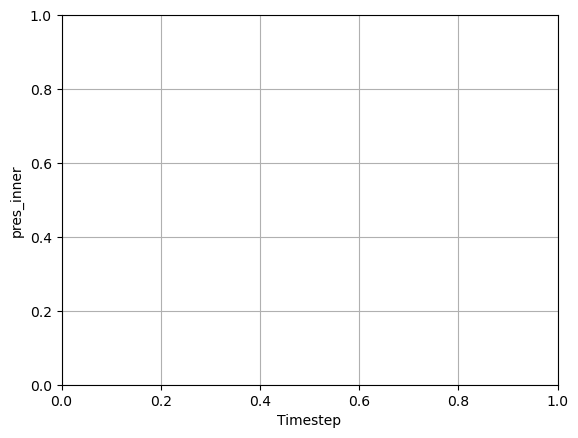

{'step': 0.01, 'outer_snes': 1, 'outer_ksp': 1, 'vel_iters': 1, 'pres_iters': 1, 'vel_inner': None, 'pres_inner': None}


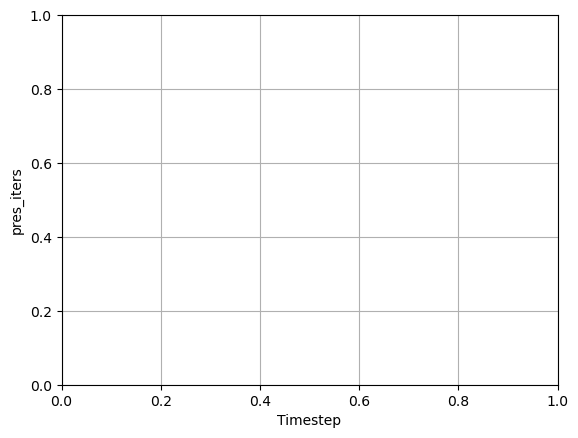

In [63]:
steps = [d["step"] for d in iteration_monitor.iteration_log]

# for s in ['outer', 'inner']:
fig = plt.figure(layout='constrained', figsize=(10, 4))
subfigs = fig.subfigures(1, 2, wspace=0.07)
subfig, ax = plt.subplots()
m = ['+','x','o']
for s in ['outer','inner','pres_iters']:
  for idx, k in enumerate([kk for kk in iteration_monitor.iteration_log[0].keys() if s in kk]):
    # plt.figure(figsize=(8,4))
    ax.plot(steps, [d[k] for d in iteration_monitor.iteration_log], marker=m[idx], label=k)
    plt.xlabel("Timestep")
    plt.ylabel(k)#"Outer KSP Iterations")
    # plt.title("Iteration Count vs Timestep")
    plt.grid(True)
    print(iteration_monitor.iteration_log[idx])
  ax.legend()#loc='upper left')
  plt.show()

# Additional topics
Semi-Implicit Method for Pressure-Linked Equations (SIMPLE):

$$
{\Sigma}_{SIMPLE} = \begin{bmatrix}
C^{n+1} & 0 \\ -B & \widetilde{S}_{SIMPLE}
\end{bmatrix}\begin{bmatrix}
I & -\mathrm{diag}(C^{n+1})^{-1}\,B^T \\ 0 & I
\end{bmatrix}
$$
$$
\text{with }\widetilde{S}_{SIMPLE} = B\, \mathrm{diag}(C^{n+1})^{-1}\, B^T
$$
Reference: https://doi.org/10.1016/j.jcp.2007.09.026

In [32]:
USE_SIMPLE_AS_SOLVER = True

if USE_SIMPLE_AS_SOLVER:
  dt = 0.002
else:
  dt = 0.01

# Original monolithic problem
bc_in_ORIG = DirichletBC(W.sub(0), u_in, 1)
bc_obs_ORIG = DirichletBC(W.sub(0), Constant((0.,0.)), 5)
bc_wall_ORIG = DirichletBC(W.sub(0).sub(1), Constant(0.), (3,4))
bcs_ORIG = (bc_in_ORIG, bc_obs_ORIG, bc_wall_ORIG)
a, L = monolithic_forms(uu, vv, pp, qq, Re, dt, u_in, uh_old, ph_old)
# as trial we have used "du, dp": they are just TrialFunctions: name doesn't matter
pb_ORIG = LinearVariationalProblem(a, L, wh, bcs=bcs_ORIG)

param = {} # define it before if to avoid name clash (i.e. "multiple instances of param")
if USE_SIMPLE_AS_SOLVER:
  # SIMPLE - directly extracted from the original problem
  # AND USED AS A SOLVER.
  # They are the same parameters as in the Chorin-Temam case!
  # But we will apply them to the ORIGINAL monolithic problem,
  # so S is NOT -B*inv(diag(M))*B^T , but rather -B*inv(diag(A00))*B^T with the full vel-vel block A00
  param = {'':''
          # using as a SOLVER
          , 'ksp_type': 'preonly'
          # FIELDSPLIT LDU FACTORIZATION
          , 'pc_type': 'fieldsplit'   # exploit block structure
          , 'pc_fieldsplit_type': 'schur' # LU factorization type that is based on the computation of the Schur complement
          , 'pc_fieldsplit_schur_fact_type': 'full'
          # PARAMETERS TO "INVERT" VEL-VEL BLOCK. BEWARE: THEY ARE USED ALSO TO ASSEMBLE S
          , 'fieldsplit_0_ksp_type': 'preonly'    # direct solver for matrix A00
          , 'fieldsplit_0_pc_type': 'lu'
          # PARAMETERS TO "INVERT" APPROXIMATE SCHUR COMPLEMENT USING diag(A00)
          , 'pc_fieldsplit_schur_precondition': 'selfp'    # assemble S as S=A11-A10*inv(diag(A00))*A01: thanks to diag, inv is actually assembled!
          , "fieldsplit_1_mat_schur_complement_ainv_type": "diag" # lump/diag approach to approximate inv(A00) in the Schur complement
          , "fieldsplit_1_ksp_type": "preonly"    # solver for S (direct solver allowed because of selfp)
          , "fieldsplit_1_pc_type": "lu"  # preconditioner for S
          # PARAMETERS TO "INVERT" VEL-VEL BLOCK IN THE UPPER-TRIANGULAR COMPONENT (DEFAULT = as fieldsplit_0_).
          , 'fieldsplit_0_ksp_type': 'preonly'    # direct solver for matrix A00
          , 'fieldsplit_0_pc_type': 'jacobi'
          , 'fieldsplit_0_pc_jacobi_type': 'diagonal'
  }
else:
  # SIMPLE USED AS A PRECONDITIONER
  param = {'':''
          # using SIMPLE as a PRECONDITIONER
          , 'ksp_type': 'gmres'
          , 'ksp_rtol': 1e-6
          # FIELDSPLIT LDU FACTORIZATION
          , 'pc_type': 'fieldsplit'   # exploit block structure
          , 'pc_fieldsplit_type': 'schur' # LU factorization type that is based on the computation of the Schur complement
          , 'pc_fieldsplit_schur_fact_type': 'full'
          # PARAMETERS TO "INVERT" VEL-VEL BLOCK. BEWARE: THEY ARE USED ALSO TO ASSEMBLE S
          , 'fieldsplit_0_ksp_type': 'preonly'    # solver for matrix A00
          , 'fieldsplit_0_pc_type': 'lu'
          # PARAMETERS TO "INVERT" APPROXIMATE SCHUR COMPLEMENT USING diag(A00)
          , 'pc_fieldsplit_schur_precondition': 'selfp'    # assemble S as S=A11-A10*inv(diag(A00))*A01: thanks to diag, inv is actually assembled!
          , "fieldsplit_1_ksp_type": "preonly"    # solver for S
          , 'fieldsplit_1_pc_type': 'lu'
          # PARAMETERS TO "INVERT" VEL-VEL BLOCK IN THE UPPER-TRIANGULAR COMPONENT (DEFAULT = as fieldsplit_0_).
          , 'fieldsplit_0_upper_ksp_type': 'preonly'
          , 'fieldsplit_0_upper_pc_type': 'jacobi'
          , 'fieldsplit_0_upper_pc_jacobi_type': 'diagonal'
  }

solver_SIMPLE = LinearVariationalSolver(pb_ORIG, solver_parameters=param)

# Function solving 1 time step:
# - before the call: uh_old, ph_old contain the solution at the previous time step t^n
# - during the call: uh_old, ph_old, du_tilde and possibly other variables change, as long as they are correctly linked together
# - after the call: uh_old, ph_old contain the solution at the previous time step t^{n+1}
def solve_1_timestep():

    solver_SIMPLE.solve()
    alpha = 0.01

    # Update old solution.
    uh, ph = wh.subfunctions
    uh_old.assign(uh)
    ph_old.dat += alpha*ph.dat

    # No need to re-assign BCs to uh_old: they are not imposed incrementally


In [33]:
# Initialization (already done above, but re-introducing it here makes the notebook more robust w.r.t. running cells in a different order... as done below for SIMPLE)
wh.assign(0)
du_tilde.assign(0)
uh_old.assign(uh_init)
ph_old.assign(ph_init)

t_vec = [0.0] + (dt + np.arange(0.0, T, dt)).tolist()
drag_vec = [0.0] * len(t_vec)
lift_vec = [0.0] * len(t_vec)
normal = FacetNormal(mesh)
drag_vec[0] = assemble(inner(ph_old*normal - 2.0/Re*dot(sym(grad(uh_old)), normal), Constant((1.,0.))) * ds(5))
lift_vec[0] = assemble(inner(ph_old*normal - 2.0/Re*dot(sym(grad(uh_old)), normal), Constant((0.,1.))) * ds(5))
iters = [solver.snes.ksp]
for ii in range(1, len(t_vec)):     # start from 1 to skip t=0
    t = t_vec[ii]
    print('------------------------------\n t =', t, '\n------------------------------')
    print('------ ||u||_{H^1} =', norm(uh_old,'H1'), '  ||p||_{L^2} =', norm(ph_old,'L2')) # to check the solution is not blowing up

    solve_1_timestep()

    print('------ # iter block linear solver = ', solver.snes.ksp.getIterationNumber(), flush=True)

    # Post-processing
    outfile.write(uh_old, ph_old, time=t)

    drag_vec[ii] = assemble(inner(ph_old*normal - 2.0/Re*dot(sym(grad(uh_old)), normal), Constant((1.,0.))) * ds(5))
    lift_vec[ii] = assemble(inner(ph_old*normal - 2.0/Re*dot(sym(grad(uh_old)), normal), Constant((0.,1.))) * ds(5))

    print('------ drag =', drag_vec[ii], '   lift =', lift_vec[ii])

------------------------------
 t = 0.002 
------------------------------
------ ||u||_{H^1} = 9.498633156400926   ||p||_{L^2} = 0.8837185479968951
------ # iter block linear solver =  0
------ drag = -3.392092723368751    lift = 0.1877148824885642
------------------------------
 t = 0.004 
------------------------------
------ ||u||_{H^1} = 56.29938021959549   ||p||_{L^2} = 103.52757057719354
------ # iter block linear solver =  0
------ drag = -2.3642182673869683    lift = 0.2120163293081318
------------------------------
 t = 0.006 
------------------------------
------ ||u||_{H^1} = 29.558500878506216   ||p||_{L^2} = 100.58214461515566
------ # iter block linear solver =  0
------ drag = -2.036811290814186    lift = 0.17244730014279197
------------------------------
 t = 0.008 
------------------------------
------ ||u||_{H^1} = 19.059601624122763   ||p||_{L^2} = 98.67249112657434
------ # iter block linear solver =  0
------ drag = -2.025682907816635    lift = 0.1794452549270011
-

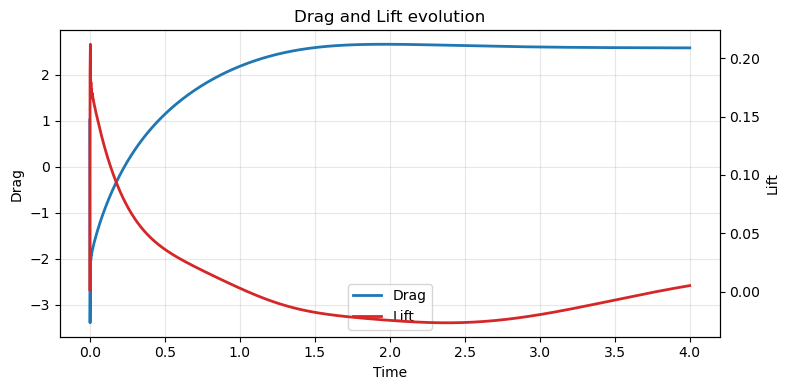

In [34]:
fig, ax1 = plt.subplots(figsize=(8, 4))

t_vec = [0.0] + (dt + np.arange(0.0, T, dt)).tolist()

# Drag axis
line1 = ax1.plot(
    t_vec, drag_vec,
    label='Drag',
    linewidth=2
)
ax1.set_xlabel('Time')
ax1.set_ylabel('Drag')
ax1.grid(True, alpha=0.3)

# Lift axis
ax2 = ax1.twinx()

line2 = ax2.plot(
    t_vec, lift_vec,
    label='Lift',
    color='tab:red',
    linewidth=2
)

ax2.set_ylabel('Lift')
ax2.tick_params(axis='y')

# Combined legend
lines = line1 + line2
labels = [l.get_label() for l in lines]

ax1.legend(
    lines,
    labels,
    loc='lower center',
    frameon=True
)

plt.title('Drag and Lift evolution')
plt.tight_layout()
plt.show()

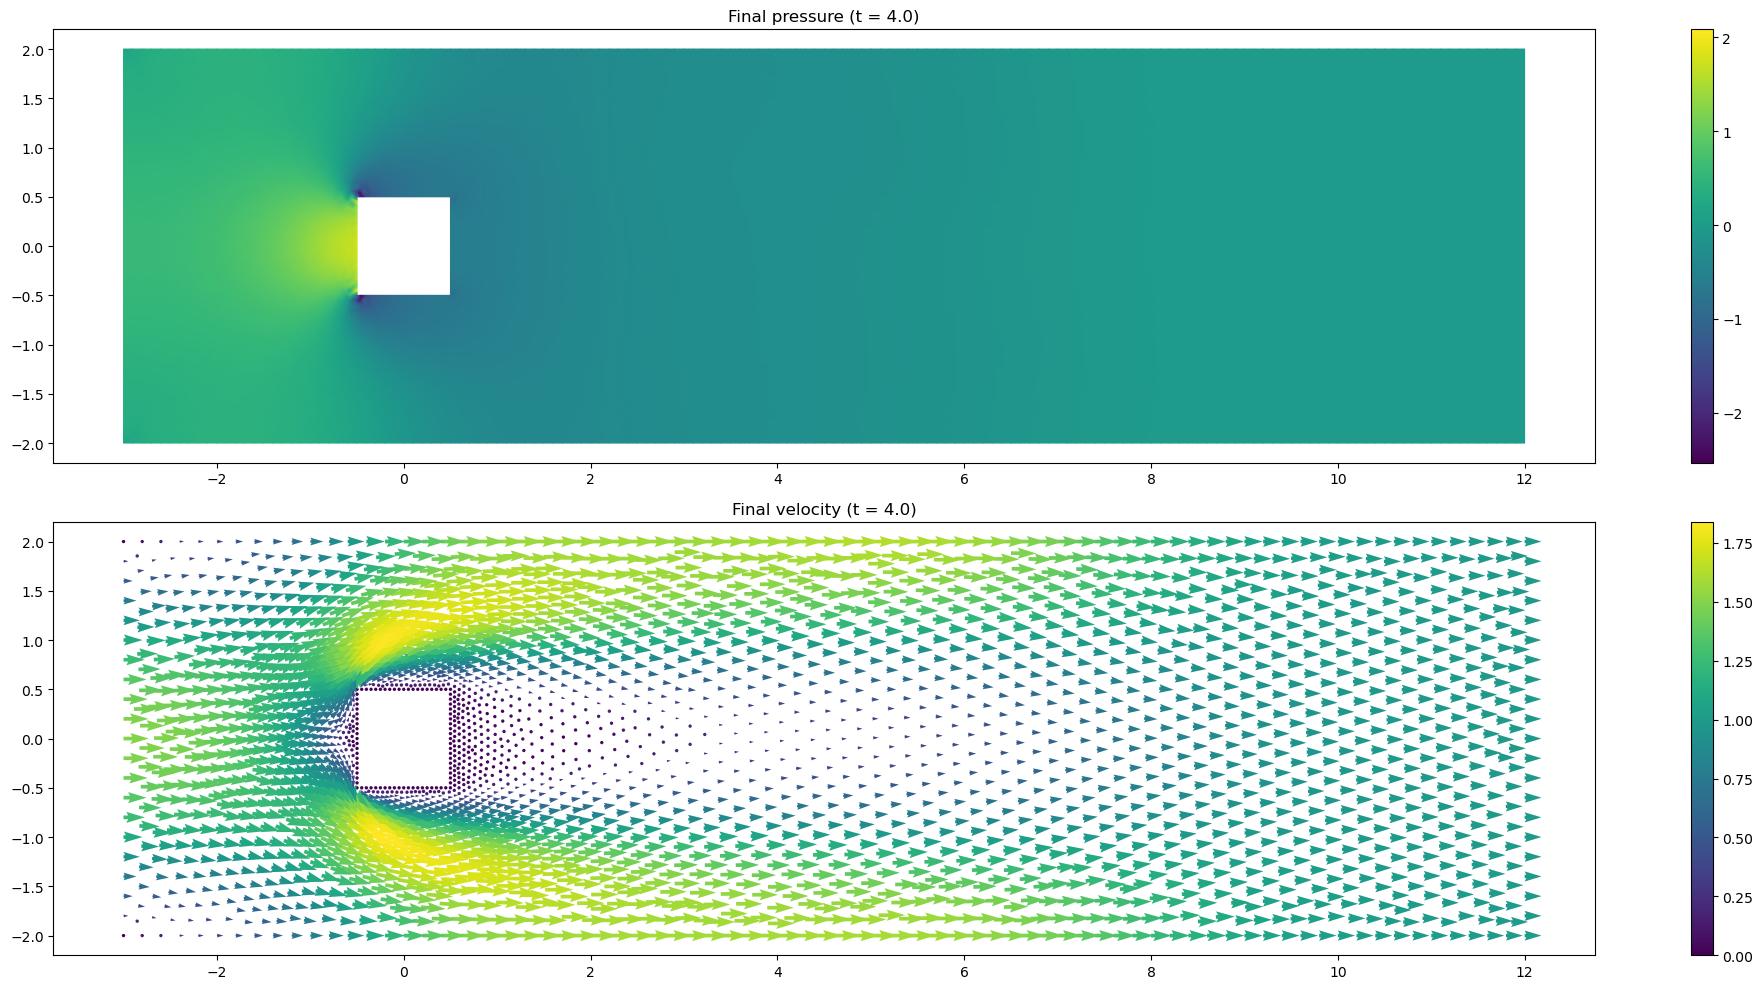

In [35]:
fig, ax = plt.subplots(2, 1, figsize=(20, 10))

col0 = tripcolor(ph_old, axes=ax[0])
fig.colorbar(col0, ax=ax[0])
ax[0].set_title('Final pressure (t = {})'.format(t_vec[-1]))

col1 = quiver(uh_old, axes=ax[1])
fig.colorbar(col1, ax=ax[1])
ax[1].set_title('Final velocity (t = {})'.format(t_vec[-1]))

plt.tight_layout()